In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

%matplotlib inline

In [3]:
df = pd.read_csv("FuelConsumptionCo2.csv")

# visualizar dentro del set de datos
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
# Sumarizar los datos
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [5]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


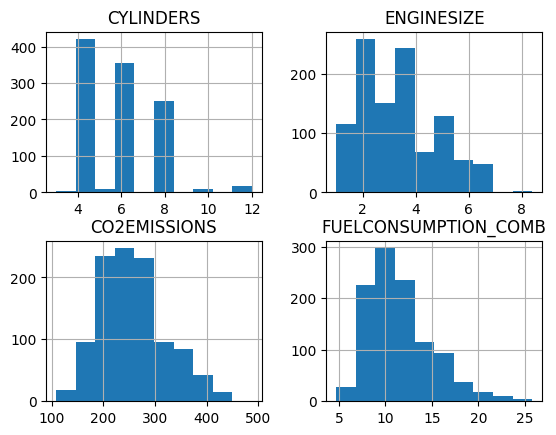

In [6]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()

plt.show()

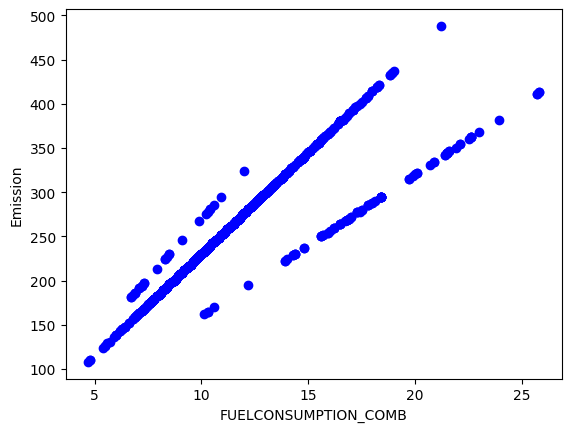

In [7]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

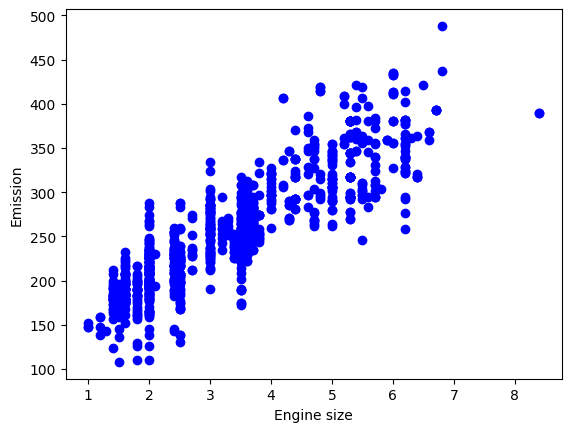

In [8]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

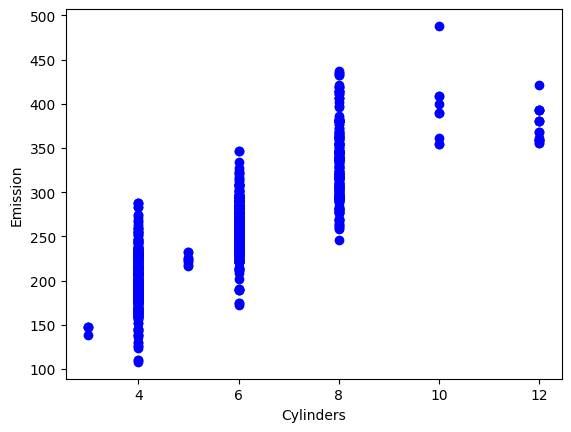

In [9]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

In [11]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

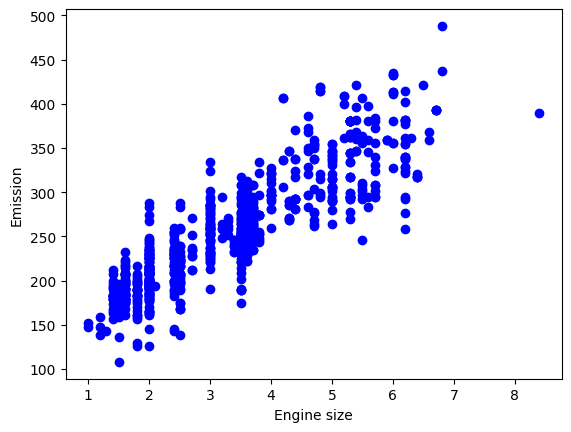

In [12]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [13]:
from sklearn import linear_model

regr = linear_model.LinearRegression()

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

regr.fit(train_x, train_y)

# The coefficients
print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Coefficients:  [[39.5214822]]
Intercept:  [124.80128323]


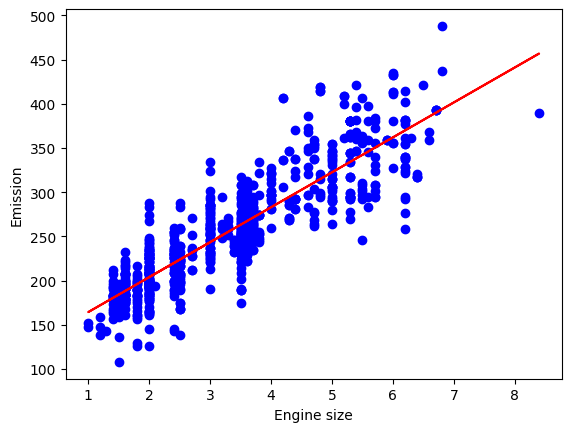

In [14]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [15]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

test_y_ = regr.predict(test_x)

print("Error medio absoluto: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Suma residual de los cuadrados (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y, test_y_))

Error medio absoluto: 24.00
Suma residual de los cuadrados (MSE): 959.90
R2-score: 0.75


## Entregables

### 1. Resultados de la ejecución de los comandos

Coeficiente: 39.5214822  
Intercepto: 124.80128323  

Error medio absoluto: 24.00  
Suma residual de los cuadrados (MSE): 959.90  
R2-score: 0.75  

### 2. Polinomio generado por el modlo de regresión

CO2EMISSIONS = 39.5214822(ENGINESIZE) + 124.80128323

### 3. Análisis de la precisión del modelo

El modelo de regresión lineal simple fue usado para poder predecir las emisiones de CO2 de los vehiculos usando como variable independiente el tamaño del motor. El resultado del R2-score fue de 0.75 por lo que muedtra que el modelo explica aproximadamente el 75% de la variacion de las emisiones de CO2, esto significa que el modelo tiene una precision que se acepta.El error medio absoluto fue de 24.00, lo que muestra que las predicciones del modelo se equivocan en promedio por aproximadamente 24 unidades.

En conclusion, el tamaño del motor si tiene una relacion importante con las emisiones de CO2, aunque no explica el 100% de los casos.

In [16]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [17]:
X = cdf[['ENGINESIZE']]
y = cdf['CO2EMISSIONS']

modelo = LinearRegression()

kf_scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R2 de cada fold:")
print(kf_scores)

print("R2 promedio:")
print(kf_scores.mean())

R2 de cada fold:
[0.74334613 0.7838278  0.72801992 0.73032948 0.78636053]
R2 promedio:
0.7543767707250393


In [18]:
X = cdf[['CYLINDERS']]
y = cdf['CO2EMISSIONS']

modelo = LinearRegression()

kf_scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R2 de cada fold:")
print(kf_scores)

print("R2 promedio:")
print(kf_scores.mean())

R2 de cada fold:
[0.65810707 0.74177792 0.68744848 0.72604605 0.68273581]
R2 promedio:
0.6992230656221439


In [19]:
X = cdf[['FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

modelo = LinearRegression()

kf_scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R2 de cada fold:")
print(kf_scores)

print("R2 promedio:")
print(kf_scores.mean())

R2 de cada fold:
[0.80635939 0.61504724 0.75348483 0.85080731 0.86748489]
R2 promedio:
0.7786367313653596


In [20]:
X = cdf[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

modelo = LinearRegression()

kf_scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R2 de cada fold:")
print(kf_scores)

print("R2 promedio:")
print(kf_scores.mean())

R2 de cada fold:
[0.88051915 0.76909654 0.81958305 0.88490155 0.89558377]
R2 promedio:
0.8499368120958024


# Reto

## 1. K-Fold Cross Validation

Se aplico validacion cruzada K-Fold con 5 particiones para evaluar las distintas variables predictoras.

Resultados obtenidos
- ENGINESIZE: R² = 0.7544
- CYLINDERS: R² = 0.6992
- FUELCONSUMPTION_COMB: R² = 0.7786
- Regresión múltiple (ENGINESIZE + CYLINDERS + FUELCONSUMPTION_COMB): R² = 0.8494

El modelo que tuvo mejor precisión fue la regresión multiple obteniendo un R² promedio de 0.8494.

## 2. Analisis de variables y regresión multiple

Se construyó un modelo de regresión multiple usando las variables ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB.

El modelo obtuvo un R² promedio de 0.8494, mayor al obtenido por cualquier variable individual.

Esto muestra que poder combinar varias caracteristicas del vehiulo permite mejorar la capacidad predictiva del modelo para estimar las emisiones de CO2.

## 3. Variables poco significativas

Cuando se compara los resultados individuales obtenidos mediante K-Fold Cross Validation se observo:

- FUELCONSUMPTION_COMB: R² = 0.7786
- ENGINESIZE: R² = 0.7544
- CYLINDERS: R² = 0.6992

La variable CYLINDERS presenta el menor desempeño predictivo individual por lo que puede considerarse la menos significativa dentro de las variables analizadas.

Las variables más notorias fueron FUELCONSUMPTION_COMB y ENGINESIZE.